
### Product-Partition Models

!["title"](tbale.png)


So essentially how to get $S(n, p)$. We want to count the number of ways of partitioning $n$ objects into $p$ partitions. So we can write the multinomial coefficient $\binom{n}{n_1, n_2, \dots n_p}$. This gives an ordered group i.e if $y_1, y_2, y_3, y_4$ then $(y_1, y_2), (y_3, y_4)$ is separate from $(y_3, y_4), (y_1, y_2)$, hence we divide by $2!$. For the more general case given in the text there are $(p-4)$ clusters of size $a$ and $2$ clusters of size $b$ and $2$ clusters of size $c$, hence we divide by $(p-4)! 2! 2!$

The number of configuration classes within a cluster class $p$. Essentially how many ways can we divide up a number into $p$ parts. If n = 4, and p = 2 then its two ways $1, 3$ and $2,2$. This is given by $b(n, p)$. So if we have $n$ items then the number of ways to form $p$ clusters out of them is $b(n, p)$. And $b(n, p) = b(n-1, p-1) + b(n-p, p), 1 \leq p \leq n$ and $b(n, 1) = 1, b(n, n) = 1$

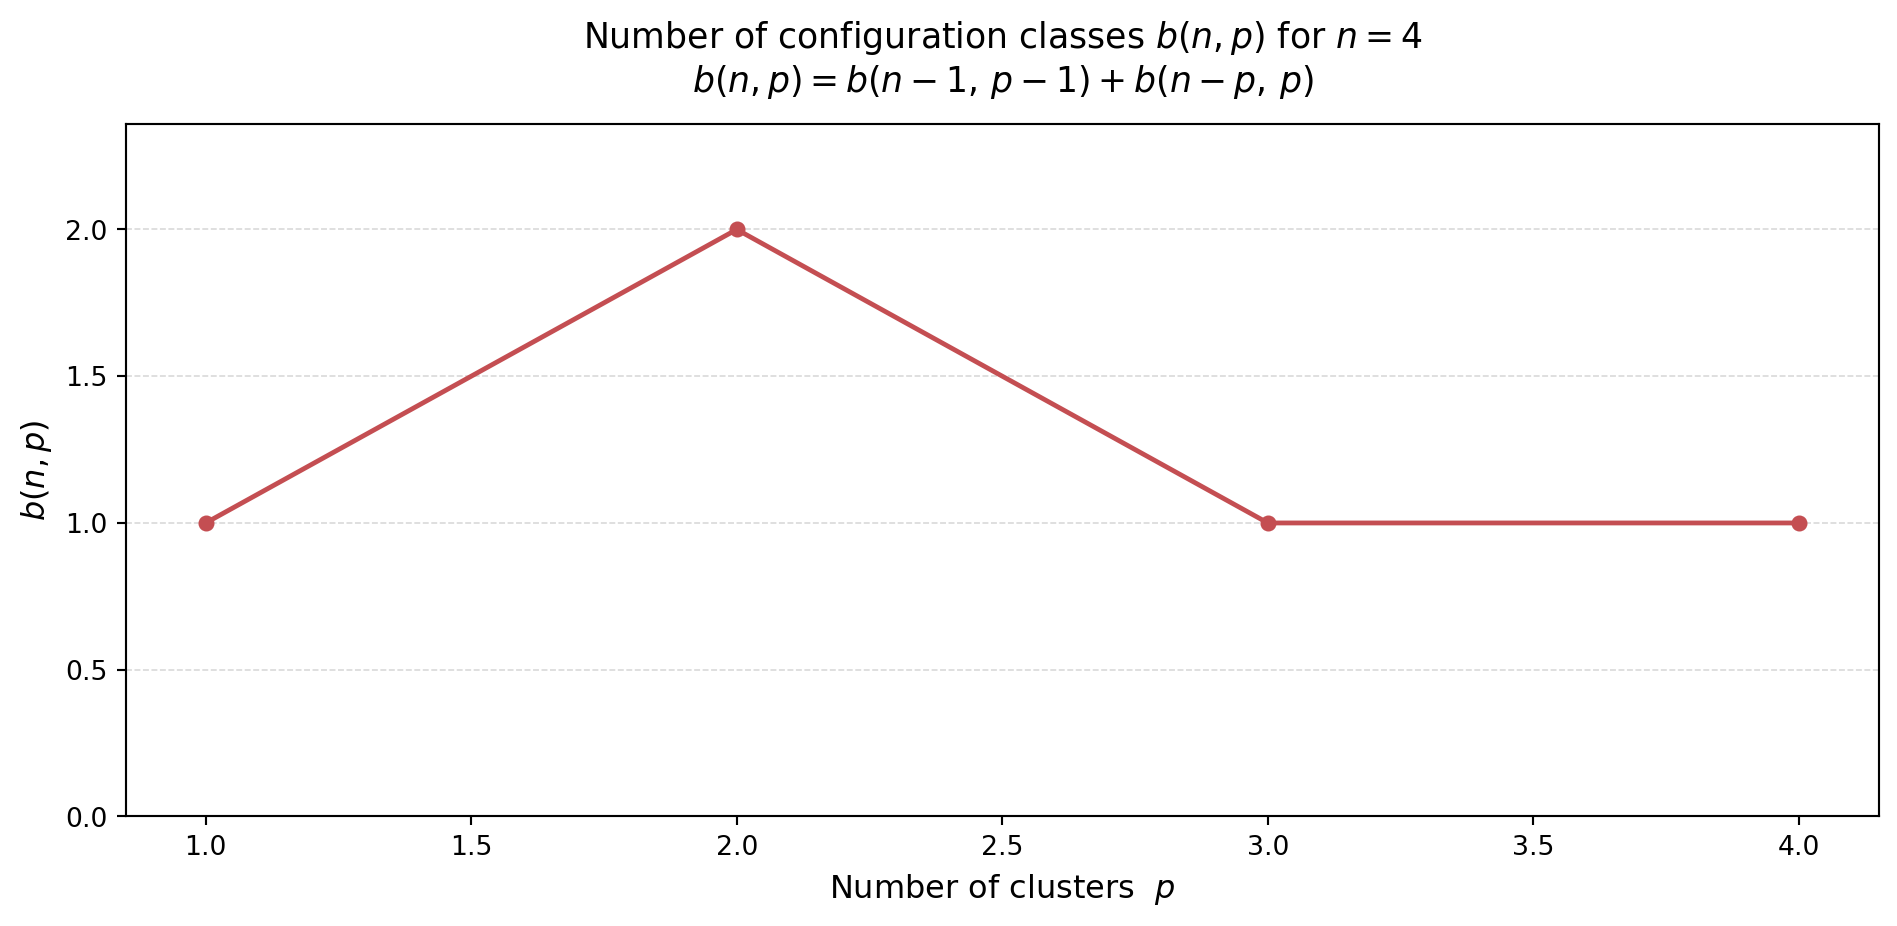

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
from functools import lru_cache
import matplotlib.ticker as ticker

# ------------------------------------------------------------
# Recurrence:  b(n,p) = b(n-1,p-1) + b(n-p,p)
# Base cases:  b(n,1) = 1,  b(n,n) = 1
# ------------------------------------------------------------
@lru_cache(maxsize=None)
def b(n, p):
    if p < 1 or p > n:
        return 0
    if p == 1 or p == n:
        return 1
    return b(n - 1, p - 1) + b(n - p, p)


n      = 4
p_vals = list(range(1, n + 1))
b_vals = [b(n, p) for p in p_vals]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))

# Overlay line + markers
ax.plot(p_vals, b_vals, color="#C44E52", linewidth=1.8,marker="o", markersize=5, zorder=4)
ax.set_xlabel("Number of clusters  $p$", fontsize=12)
ax.set_ylabel("$b(n,p)$", fontsize=12)
ax.set_title(
    "Number of configuration classes $b(n,p)$ for $n = 4$\n"
    r"$b(n,p) = b(n-1,\,p-1) + b(n-p,\,p)$",
    fontsize=13, pad=12
)

ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5, zorder=0);
ax.set_ylim(0, max(b_vals) * 1.18);

plt.tight_layout();
plt.show()

So there are greater number of ways to divide a group of 4 objects into 2 clusters than to divide them into 1 or 3 or 4 clusters. Within each clusters class e.g. for 2 clusters class there are 7 clusters possible , for 4 and 1 clusters there is only 1 and for 3 there are 6 clusters possible. Now $R_p = \sum_{n_c } R_{n_c, p}$ where I have $R_2 = R_{(4 = 1+3), 2} + R_{(4 = 2+ 2), 2}$ and of course this number is much greater than $b(n, p) = 2$. For this case $R_2 = 7$

Known issues with Mixture Models.
1. In mixture models, label switching comes from the fact that component labels (1, 2, …, K) are arbitrary — swapping them does not change the model or likelihood. This is because we usually do $\sum_k \pi_k L(x|k)$ and hence we can switch the labeling on the parameters. In MCMC, this causes the chain to move between equivalent parameterizations (e.g., component 1 and 2 swapping roles), because it explores the full symmetric posterior. In EM or gradient descent, there is no switching during optimization; instead, the algorithm converges to one of the equivalent optima depending on initialization. Different runs may end up with permuted labels.



So we introduce product partition models the notation is a bit clunky but its pretty self-explanatory. We need a prior over $p, r_p, \theta_p$ where $p$ is number of clusters we want $r_p$ is the partition ie partition of each point $n_i$ into one of $p$ clusters. Basically use Bayes rule etc. etc. to define the relevant quatitities above. Additionally define the Bayes factor $\frac{m(y| r_p, n)}{m(y | r_1, n)}$ which defines how well a particular partition is supported over the partition of size $1$. 
  

### Selecting priors for the clustering model...

1. Uniform Prior over Partitions.
2. Ewens - Pitman Prior
3. Jensen-Liu Prior
4. HUP (This paper...) - Basically defined by assuming that things are uniform within data generating process proposed above...


Ok so i could look into what Ewens-Pitman and Jensen-Liu are I dont know how these priors are derived... But Table 1. shows the uniform prior assigns more weight to the entropically favorable partition  while for Ewens-Pitman and Jensen-Liu the situations are reversed i.e they favor ${1, 3, 6}$ over ${2, 3, 5}$ for $R_{10, 3}$ where the prior numbers are sizes of the clusters and $\lambda = 1$ for both Ewens-Pitman and Jensen-Liu.

The HUP however - says  that $p$ should be small since we want a smaller number of clusters this is debatable... Alright but the way we derive the prior is 


1. Say that $P(p | \lambda)$ is a Poisson and $P(\lambda)$ is Jeffery's Prior and now integrate out $\lambda$ to get $P(p| n)$ where we truncate the to the set $1...n$ since $p$ cannot be greater than $n$.  We can get different tail behaviors by choosing different kinds of priors for the $\lambda$ parameter.

So the HUP says 

1. Select $p$ ie number of clusters we want 
2. Select one of $b(n, p)$ uniformly ie. which one of the $p$ ways of partitioning $n$ we want  i.e. whether $4 = 1 + 3$ or $4 = 2 + 2$
3. Assign uniform probabilities to all partitions within $R_p$ i.e within all cluster of class $1, 3$ all partitions are uniform and so on...


Jensen-Liu and Uniform favor large number of clusters with fewer points in each cluster. While Ewens-Pitman and HUP are better with HUP having a faster convergence rate.